In [1]:
import pandas as pd

In [51]:
df = pd.read_csv("super_diario.csv", parse_dates=["fecha"])

In [52]:
df

,departamento,fecha,componente,inflacion_28d,inflacion_28d_q05,inflacion_28d_q95
0,cochabamba,2024-09-01,Abarrotes,4.740,NaN,NaN
1,cochabamba,2024-09-01,Bazar,10.666,NaN,NaN
2,cochabamba,2024-09-01,Bebidas,2.504,NaN,NaN
3,cochabamba,2024-09-01,Carnes,-0.269,NaN,NaN
4,cochabamba,2024-09-01,Compuesto,2.434,NaN,NaN
...,...,...,...,...,...,...
29205,santa_cruz,2026-05-28,Frutas y Verduras,2.008,NaN,NaN
29206,santa_cruz,2026-05-28,Granos y Hortalizas,0.072,0.072,0.072
29207,santa_cruz,2026-05-28,Lácteos y Derivados,0.714,0.714,1.165
29208,santa_cruz,2026-05-28,Panadería,0.373,0.373,0.373


In [25]:
df[df.inflacion_28d_q05.notna()].groupby(["departamento", "componente"]).fecha.min().sort_values()

departamento  componente                
cochabamba    Abarrotes                    2026-04-01
la_paz        Fiambres                     2026-04-01
              Frutas y Verduras            2026-04-01
              Granos y Hortalizas          2026-04-01
              Lácteos y Derivados          2026-04-01
              Panadería                    2026-04-01
              Pastelería y Masas Típicas   2026-04-01
santa_cruz    Abarrotes                    2026-04-01
              Bazar                        2026-04-01
la_paz        Cuidado del Hogar            2026-04-01
santa_cruz    Bebidas                      2026-04-01
              Congelados                   2026-04-01
              Cuidado Personal             2026-04-01
              Cuidado del Bebé             2026-04-01
              Cuidado del Hogar            2026-04-01
              Fiambres                     2026-04-01
              Frutas y Verduras            2026-04-01
              Granos y Hortalizas        

In [26]:
df

,departamento,fecha,componente,inflacion_28d,inflacion_28d_q05,inflacion_28d_q95
0,cochabamba,2024-09-01,Abarrotes,4.827,NaN,NaN
1,cochabamba,2024-09-01,Bazar,10.774,NaN,NaN
2,cochabamba,2024-09-01,Bebidas,2.510,NaN,NaN
3,cochabamba,2024-09-01,Carnes,-0.269,NaN,NaN
4,cochabamba,2024-09-01,Compuesto,2.455,NaN,NaN
...,...,...,...,...,...,...
29205,santa_cruz,2026-05-28,Frutas y Verduras,2.008,2.008,3.265
29206,santa_cruz,2026-05-28,Granos y Hortalizas,0.072,0.072,0.072
29207,santa_cruz,2026-05-28,Lácteos y Derivados,0.714,0.714,1.282
29208,santa_cruz,2026-05-28,Panadería,0.373,0.373,0.373


In [ ]:
df[df.inflacion_28d_q05.notna()].groupby(["departamento", "componente"]).fecha.min().sort_values()

<Axes: xlabel='fecha'>

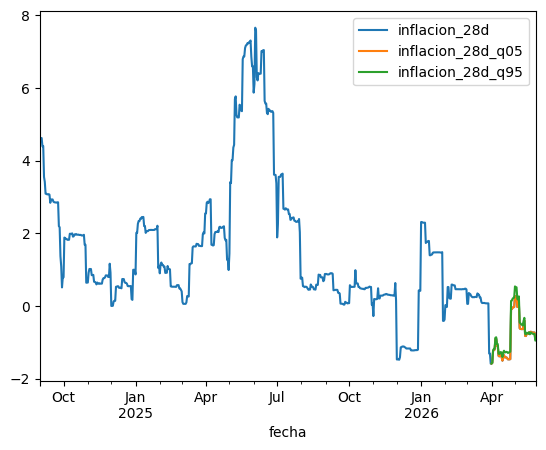

In [24]:
df[(df.departamento == "la_paz") & (df.componente == "Abarrotes")].set_index("fecha")[
    ["inflacion_28d", "inflacion_28d_q05", "inflacion_28d_q95"]
].plot()

In [22]:
df[(df.departamento == "santa_cruz") & (df.componente == "Abarrotes") & (df.fecha >= "2026-04-01")]

,departamento,fecha,componente,inflacion_28d,inflacion_28d_q05,inflacion_28d_q95
26572,santa_cruz,2026-04-01,Abarrotes,-0.167,-0.167,-0.164
26618,santa_cruz,2026-04-02,Abarrotes,-0.063,-0.063,-0.057
26664,santa_cruz,2026-04-03,Abarrotes,-0.061,-0.061,-0.052
26710,santa_cruz,2026-04-04,Abarrotes,0.004,0.004,0.017
26756,santa_cruz,2026-04-05,Abarrotes,0.050,0.050,0.065
26802,santa_cruz,2026-04-06,Abarrotes,0.050,0.050,0.068
26848,santa_cruz,2026-04-07,Abarrotes,0.145,0.145,0.166
26894,santa_cruz,2026-04-08,Abarrotes,0.165,0.165,0.190
26940,santa_cruz,2026-04-09,Abarrotes,0.138,0.138,0.166
26986,santa_cruz,2026-04-10,Abarrotes,0.129,0.129,0.161


<Axes: xlabel='fecha'>

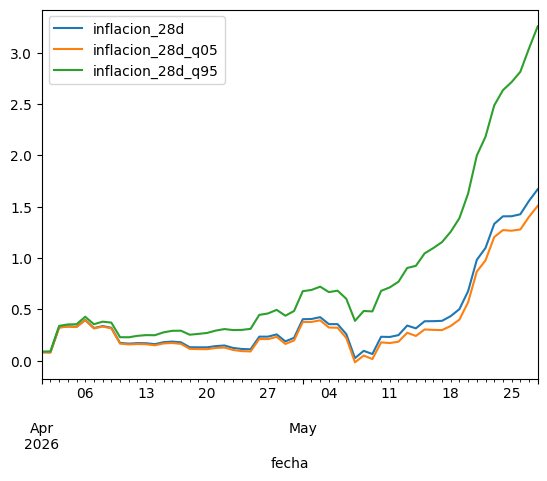

In [56]:
df[(df.departamento == "la_paz") & (df.componente == "Compuesto") & (df.fecha >= "2026-04-01")].set_index("fecha")[
    ["inflacion_28d", "inflacion_28d_q05", "inflacion_28d_q95"]
].plot()

In [ ]:
df[(df.departamento == "santa_cruz") & (df.componente == "Abarrotes") & (df.fecha >= "2026-04-01")]

In [39]:
dfi = df[(df.departamento == "santa_cruz") & (df.fecha >= "2026-04-01") & (df.inflacion_28d_q05.notna())]

In [41]:
dfi["brecha"] = dfi.inflacion_28d_q95 - dfi.inflacion_28d_q05

/tmp/ipykernel_279742/2771980111.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfi["brecha"] = dfi.inflacion_28d_q95 - dfi.inflacion_28d_q05


In [45]:
dfi.groupby("componente").brecha.mean().sort_values()

componente
Panadería                     0.000000
Granos y Hortalizas           0.000000
Bebidas                       0.057914
Lácteos y Derivados           0.131362
Carnes                        0.162091
Abarrotes                     0.168034
Fiambres                      0.238483
Cuidado del Hogar             0.324328
Cuidado Personal              0.350672
Compuesto                     0.595621
Frutas y Verduras             0.954810
Pastelería y Masas Típicas    1.477776
Bazar                         1.534224
Congelados                    1.573293
Cuidado del Bebé              3.946379
Name: brecha, dtype: float64

In [43]:
dfi.sort_values("brecha")

,departamento,fecha,componente,inflacion_28d,inflacion_28d_q05,inflacion_28d_q95,brecha
26678,santa_cruz,2026-04-03,Panadería,0.376,0.376,0.376,0.000
26676,santa_cruz,2026-04-03,Granos y Hortalizas,0.072,0.072,0.072,0.000
26584,santa_cruz,2026-04-01,Granos y Hortalizas,0.072,0.072,0.072,0.000
26586,santa_cruz,2026-04-01,Panadería,0.376,0.376,0.376,0.000
28748,santa_cruz,2026-05-18,Panadería,0.371,0.371,0.371,0.000
...,...,...,...,...,...,...,...
29017,santa_cruz,2026-05-24,Cuidado del Bebé,-1.047,-2.033,3.445,5.478
29063,santa_cruz,2026-05-25,Cuidado del Bebé,-1.047,-2.037,3.463,5.500
29109,santa_cruz,2026-05-26,Cuidado del Bebé,-1.055,-2.049,3.473,5.522
29155,santa_cruz,2026-05-27,Cuidado del Bebé,-1.149,-2.145,3.393,5.538


<Axes: xlabel='fecha'>

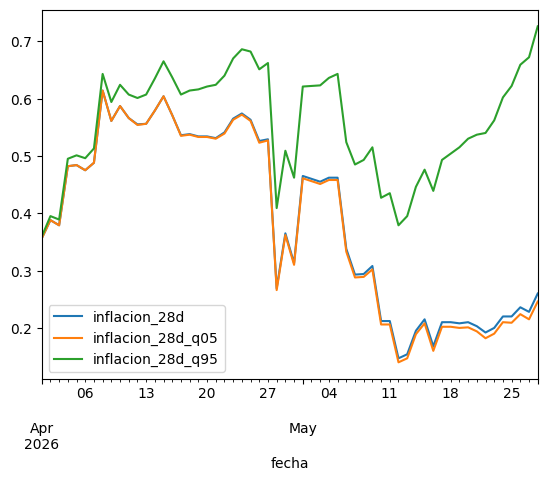

In [55]:
df[(df.departamento == "santa_cruz") & (df.componente == "Compuesto") & (df.fecha >= "2026-04-01")].set_index("fecha")[
    ["inflacion_28d", "inflacion_28d_q05", "inflacion_28d_q95"]
].plot()

<Axes: xlabel='fecha'>

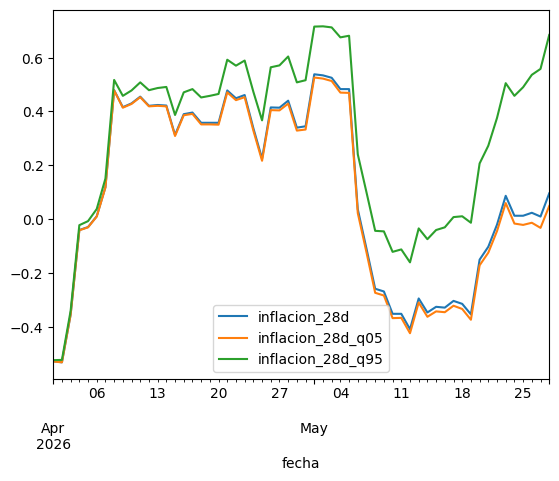

In [54]:
df[(df.departamento == "cochabamba") & (df.componente == "Compuesto") & (df.fecha >= "2026-04-01")].set_index("fecha")[
    ["inflacion_28d", "inflacion_28d_q05", "inflacion_28d_q95"]
].plot()